In [ ]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
import matplotlib.patheffects as pe
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
from scipy import stats
from scipy.spatial import ConvexHull
from scipy.ndimage import gaussian_filter
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.neighbors import KernelDensity
import warnings
warnings.filterwarnings("ignore")

PROJECT_ROOT = Path.cwd().parent.parent
sys.path.insert(0, str(PROJECT_ROOT))

PROCESSED  = PROJECT_ROOT / "data" / "processed"
OUTPUT_DIR = Path.cwd() / "outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

SEPHORA_COLOR = "#E91E63"
ULTA_COLOR    = "#9C27B0"
SHARED_COLOR  = "#FF9800"
NEUTRAL       = "#90A4AE"
WHITE_COLOR   = "#00BCD4"
OVER_COLOR    = "#F44336"   # overpriced zone
UNDER_COLOR   = "#4CAF50"   # underpriced zone

In [2]:
sephora_df = pd.read_csv(PROCESSED / "Sephora" / "sephora_segmentation.csv",
                          dtype={"product_id": str})
ulta_df    = pd.read_csv(PROCESSED / "Ulta"    / "ulta_segmentation.csv",
                          dtype={"product_id": str})
matched    = pd.read_csv(PROCESSED / "Matched" / "matched_pairs.csv",
                          dtype={"sephora_product_id": str,
                                 "ulta_product_id":    str})

def composite_scores(df, platform):
    brand_col = "brand_normalized" if "brand_normalized" in df.columns else "brand"
    all_num   = [c for c in df.columns if df[c].dtype in
                 [np.float64, np.float32, np.int64] and c != "product_id"]
    agg = (
        df.groupby(brand_col)
        .agg(n_products=(brand_col, "count"),
             **{f: (f, "mean") for f in all_num if f in df.columns})
        .reset_index()
        .rename(columns={brand_col: "brand"})
    )
    agg["platform"] = platform
    if "pct_negative" in agg.columns:
        agg["pct_positive_sentiment"] = 1 - agg["pct_negative"]
    if "avg_rating" in agg.columns and "price" in agg.columns:
        agg["rating_per_dollar"] = agg["avg_rating"] / agg["price"].replace(0, np.nan)

    scores = pd.DataFrame({"brand": agg["brand"], "platform": platform,
                            "n_products": agg["n_products"]})
    if "price" in agg.columns:
        scores["avg_price"] = agg["price"]
    if "price_vs_category_median" in agg.columns:
        scores["price_vs_median"] = agg["price_vs_category_median"]

    eff = [c for c in ["avg_rating", "pct_5_star", "pct_positive"] if c in agg.columns]
    if eff: scores["efficacy"] = agg[eff].mean(axis=1)
    exp = [c for c in ["avg_sentiment", "pct_positive_sentiment"] if c in agg.columns]
    if exp: scores["experience_quality"] = agg[exp].mean(axis=1)
    elif "pct_negative" in agg.columns:
        scores["experience_quality"] = 1 - agg["pct_negative"]
    pol = [c for c in ["rating_std", "pct_1_star",
                        "rating_dispersion_over_time"] if c in agg.columns]
    if pol: scores["polarization"] = agg[pol].mean(axis=1)
    tra = [c for c in ["reviews_per_month",
                        "review_count_normalized"] if c in agg.columns]
    if tra: scores["market_traction"] = agg[tra].mean(axis=1)
    if "rating_per_dollar" in agg.columns:
        scores["value_efficiency"] = agg["rating_per_dollar"]
    elif "price_vs_category_median" in agg.columns and "avg_rating" in agg.columns:
        scores["value_efficiency"] = (
            agg["avg_rating"] / (agg["price_vs_category_median"] + 1e-6)
        )
    return scores

s_scores = composite_scores(sephora_df, "Sephora")
u_scores = composite_scores(ulta_df,    "Ulta")
all_scores = pd.concat([s_scores, u_scores], ignore_index=True)

SCORE_COLS = [c for c in ["efficacy", "experience_quality", "polarization",
                           "market_traction", "value_efficiency"]
              if c in all_scores.columns]

# Fit shared PCA on all brand-platform observations
pca_df = (all_scores[all_scores["n_products"] >= 2]
          .dropna(subset=SCORE_COLS)
          .reset_index(drop=True))

scaler     = StandardScaler()
X_scaled   = scaler.fit_transform(pca_df[SCORE_COLS])
pca        = PCA(n_components=min(len(SCORE_COLS), 4), random_state=42)
components = pca.fit_transform(X_scaled)
pca_df["PC1"] = components[:, 0]
pca_df["PC2"] = components[:, 1]

explained = pca.explained_variance_ratio_
both_brands = set(pca_df[pca_df["platform"] == "Sephora"]["brand"]) & \
              set(pca_df[pca_df["platform"] == "Ulta"]["brand"])

print(f"Shared PCA space: {len(pca_df):,} brand-platform obs")
print(f"Shared brands   : {len(both_brands):,}")

Shared PCA space: 856 brand-platform obs
Shared brands   : 100


In [9]:
from sklearn.linear_model import LinearRegression

def compute_price_position(df, platform):
    brand_col = "brand_normalized" if "brand_normalized" in df.columns else "brand"
    feat_cols = [c for c in ["avg_rating", "avg_sentiment"] if c in df.columns]

    agg = (df.groupby(brand_col)
             .agg(avg_price=("price", "mean"),
                  n=(brand_col, "count"),
                  **{f: (f, "mean") for f in feat_cols})
             .reset_index()
             .rename(columns={brand_col: "brand"}))
    agg["platform"] = platform

    sub = agg[["avg_price"] + feat_cols].dropna()
    if len(sub) > 10 and feat_cols:
        lr = LinearRegression()
        lr.fit(sub[feat_cols], sub["avg_price"])
        agg["predicted_price"] = lr.predict(
            agg[feat_cols].fillna(agg[feat_cols].mean())
        )
        agg["price_position"] = agg["avg_price"] - agg["predicted_price"]
    else:
        agg["price_position"] = np.nan

    return agg[["brand", "platform", "avg_price", "price_position"]]

s_price = compute_price_position(sephora_df, "Sephora")
u_price = compute_price_position(ulta_df,    "Ulta")
all_price = pd.concat([s_price, u_price], ignore_index=True)

# Verify both platforms computed before merging
for platform in ["Sephora", "Ulta"]:
    sub = all_price[all_price["platform"] == platform]["price_position"].dropna()
    print(f"{platform}: n={len(sub)}  "
          f"range=[{sub.min():.3f}, {sub.max():.3f}]")

# Drop any pre-existing price columns from pca_df to avoid merge collisions
price_cols = [c for c in pca_df.columns if "price" in c.lower()]
print(f"\nDropping existing columns from pca_df: {price_cols}")
pca_df = pca_df.drop(columns=price_cols, errors="ignore")

# Single clean merge
pca_df = pca_df.merge(all_price, on=["brand", "platform"], how="left")

# Confirm
for platform in ["Sephora", "Ulta"]:
    sub = pca_df[(pca_df["platform"] == platform)]["price_position"].dropna()
    print(f"pca_df {platform}: n={len(sub)}  "
          f"range=[{sub.min():.3f}, {sub.max():.3f}]")

Sephora: n=309  range=[-70.709, 279.845]
Ulta: n=588  range=[-47.196, 344.538]

Dropping existing columns from pca_df: ['avg_price', 'price_vs_median', 'avg_price_sephora_dup', 'price_position', 'avg_price_ulta_dup', 'price_position_ulta_dup']
pca_df Sephora: n=301  range=[-56.971, 279.845]
pca_df Ulta: n=555  range=[-45.754, 344.538]


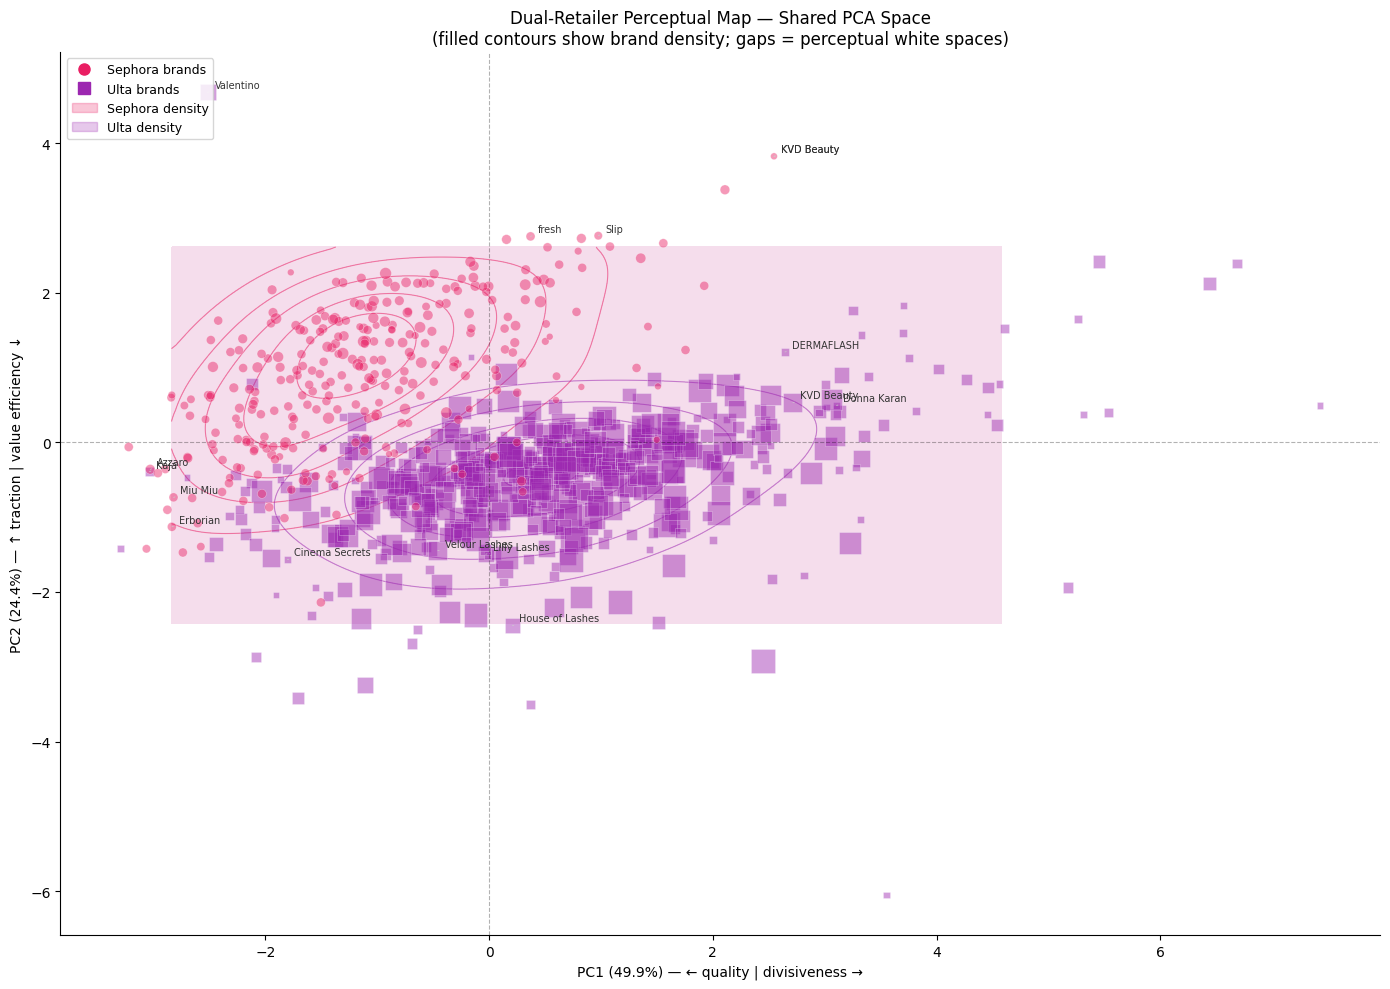

In [4]:
# Both platforms plotted together; KDE contours show where each platform's
# brands concentrate — gaps between contours = white spaces

fig, ax = plt.subplots(figsize=(14, 10))

# KDE contours for each platform
x_min, x_max = pca_df["PC1"].quantile(0.01), pca_df["PC1"].quantile(0.99)
y_min, y_max = pca_df["PC2"].quantile(0.01), pca_df["PC2"].quantile(0.99)
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                     np.linspace(y_min, y_max, 200))
grid   = np.c_[xx.ravel(), yy.ravel()]

for platform, color, alpha_fill in [("Sephora", SEPHORA_COLOR, 0.08),
                                      ("Ulta",    ULTA_COLOR,    0.08)]:
    sub = pca_df[pca_df["platform"] == platform][["PC1", "PC2"]].dropna()
    if len(sub) < 5:
        continue
    kde = KernelDensity(bandwidth=0.5, kernel="gaussian")
    kde.fit(sub.values)
    z   = np.exp(kde.score_samples(grid)).reshape(xx.shape)
    z   = gaussian_filter(z, sigma=1)
    ax.contourf(xx, yy, z, levels=5, colors=[color], alpha=alpha_fill)
    ax.contour( xx, yy, z, levels=5, colors=[color], alpha=0.5, linewidths=0.8)

# Plot brand points
for platform, color, marker, zorder in [
    ("Sephora", SEPHORA_COLOR, "o", 3),
    ("Ulta",    ULTA_COLOR,    "s", 2),
]:
    sub = pca_df[pca_df["platform"] == platform]
    ax.scatter(sub["PC1"], sub["PC2"],
               s=sub["n_products"] * 6 + 12,
               color=color, alpha=0.45, marker=marker,
               edgecolors="white", linewidths=0.4, zorder=zorder)

# Label shared brands at extreme positions
shared_sub = pca_df[pca_df["brand"].isin(both_brands)]
for extremes in [
    shared_sub.nlargest(4, "PC1"), shared_sub.nsmallest(4, "PC1"),
    shared_sub.nlargest(4, "PC2"), shared_sub.nsmallest(4, "PC2"),
]:
    for _, row in extremes.iterrows():
        ax.annotate(row["brand"],
                    xy=(row["PC1"], row["PC2"]),
                    xytext=(5, 3), textcoords="offset points",
                    fontsize=7, color="#333",
                    arrowprops=dict(arrowstyle="-", color="#ccc", lw=0.5))

ax.axvline(0, color="black", lw=0.8, ls="--", alpha=0.3)
ax.axhline(0, color="black", lw=0.8, ls="--", alpha=0.3)
ax.set_xlabel(f"PC1 ({explained[0]:.1%}) — ← quality | divisiveness →",
              fontsize=10)
ax.set_ylabel(f"PC2 ({explained[1]:.1%}) — ↑ traction | value efficiency ↓",
              fontsize=10)
ax.set_title("Dual-Retailer Perceptual Map — Shared PCA Space\n"
             "(filled contours show brand density; gaps = perceptual white spaces)",
             fontsize=12)
legend_items = [
    mlines.Line2D([], [], marker="o", color=SEPHORA_COLOR, ls="",
                  markersize=8, label="Sephora brands"),
    mlines.Line2D([], [], marker="s", color=ULTA_COLOR,    ls="",
                  markersize=8, label="Ulta brands"),
    mpatches.Patch(color=SEPHORA_COLOR, alpha=0.25, label="Sephora density"),
    mpatches.Patch(color=ULTA_COLOR,    alpha=0.25, label="Ulta density"),
]
ax.legend(handles=legend_items, fontsize=9, loc="upper left")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "3.1_shared_perceptual_space.png",
            dpi=150, bbox_inches="tight")
plt.show()

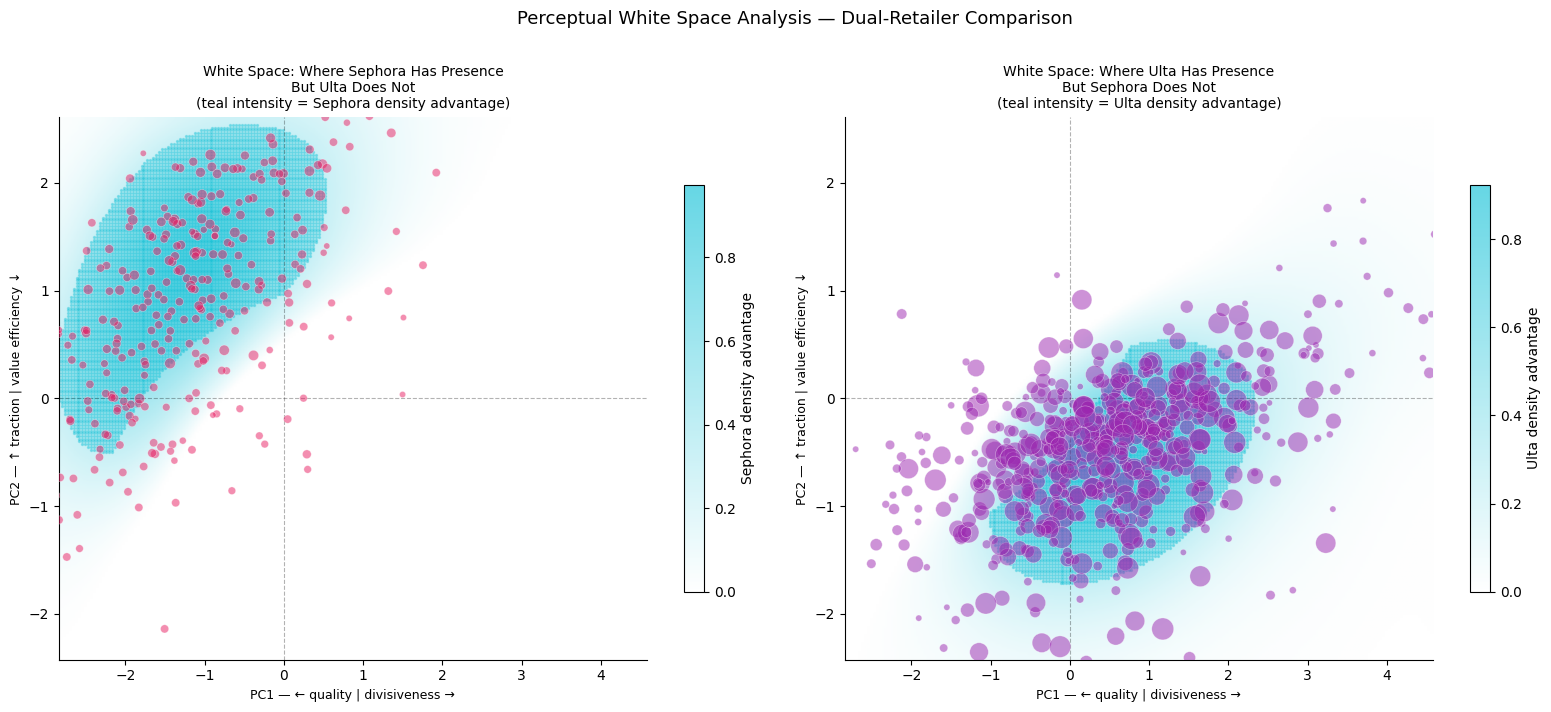

In [5]:
# Regions with high Sephora density but low Ulta density = Sephora white space on Ulta
# Regions with high Ulta density but low Sephora density = Ulta white space on Sephora

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

kdes = {}
for platform in ["Sephora", "Ulta"]:
    sub = pca_df[pca_df["platform"] == platform][["PC1", "PC2"]].dropna()
    kde = KernelDensity(bandwidth=0.6, kernel="gaussian")
    kde.fit(sub.values)
    z   = np.exp(kde.score_samples(grid)).reshape(xx.shape)
    kdes[platform] = gaussian_filter(z, sigma=1.5)

# Normalise to [0,1] for interpretable difference
for platform in ["Sephora", "Ulta"]:
    kdes[platform] = kdes[platform] / (kdes[platform].max() + 1e-10)

diff_s_minus_u = kdes["Sephora"] - kdes["Ulta"]   # +ve = Sephora denser here
diff_u_minus_s = kdes["Ulta"]    - kdes["Sephora"] # +ve = Ulta denser here

cmap_ws = LinearSegmentedColormap.from_list(
    "whitespace", ["#ffffff", "#00BCD4"], N=256
)

for ax, diff, platform, opp, brands_here in [
    (axes[0], diff_s_minus_u, "Sephora", "Ulta",
     pca_df[pca_df["platform"] == "Sephora"]),
    (axes[1], diff_u_minus_s, "Ulta", "Sephora",
     pca_df[pca_df["platform"] == "Ulta"]),
]:
    color = SEPHORA_COLOR if platform == "Sephora" else ULTA_COLOR

    # Background heatmap of the gap
    im = ax.imshow(
        np.clip(diff, 0, None),
        extent=[x_min, x_max, y_min, y_max],
        origin="lower", cmap=cmap_ws, aspect="auto", alpha=0.6,
    )
    plt.colorbar(im, ax=ax, shrink=0.75,
                 label=f"{platform} density advantage")

    # Overlay the platform's own brands
    ax.scatter(brands_here["PC1"], brands_here["PC2"],
               s=brands_here["n_products"] * 5 + 10,
               color=color, alpha=0.5, edgecolors="white",
               linewidths=0.4, zorder=3)

    # Mark white space centroids: high diff_value but low competitor density
    white_mask = (diff > 0.35) & (kdes[opp] < 0.15)
    ws_points  = np.c_[xx[white_mask], yy[white_mask]]
    if len(ws_points):
        ax.scatter(ws_points[:, 0], ws_points[:, 1],
                   s=8, color=WHITE_COLOR, alpha=0.3, marker=".", zorder=2)

    ax.axvline(0, color="black", lw=0.8, ls="--", alpha=0.3)
    ax.axhline(0, color="black", lw=0.8, ls="--", alpha=0.3)
    ax.set_xlabel(f"PC1 — ← quality | divisiveness →", fontsize=9)
    ax.set_ylabel(f"PC2 — ↑ traction | value efficiency ↓", fontsize=9)
    ax.set_title(
        f"White Space: Where {platform} Has Presence\nBut {opp} Does Not\n"
        f"(teal intensity = {platform} density advantage)",
        fontsize=10
    )
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    ax.spines[["top", "right"]].set_visible(False)

fig.suptitle("Perceptual White Space Analysis — Dual-Retailer Comparison",
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "3.1_white_space_map.png",
            dpi=150, bbox_inches="tight")
plt.show()

Sephora: n=301  price_position NaN=0  Inf=0  range=[-56.971, 279.845]
Ulta: n=555  price_position NaN=0  Inf=0  range=[-45.754, 344.538]


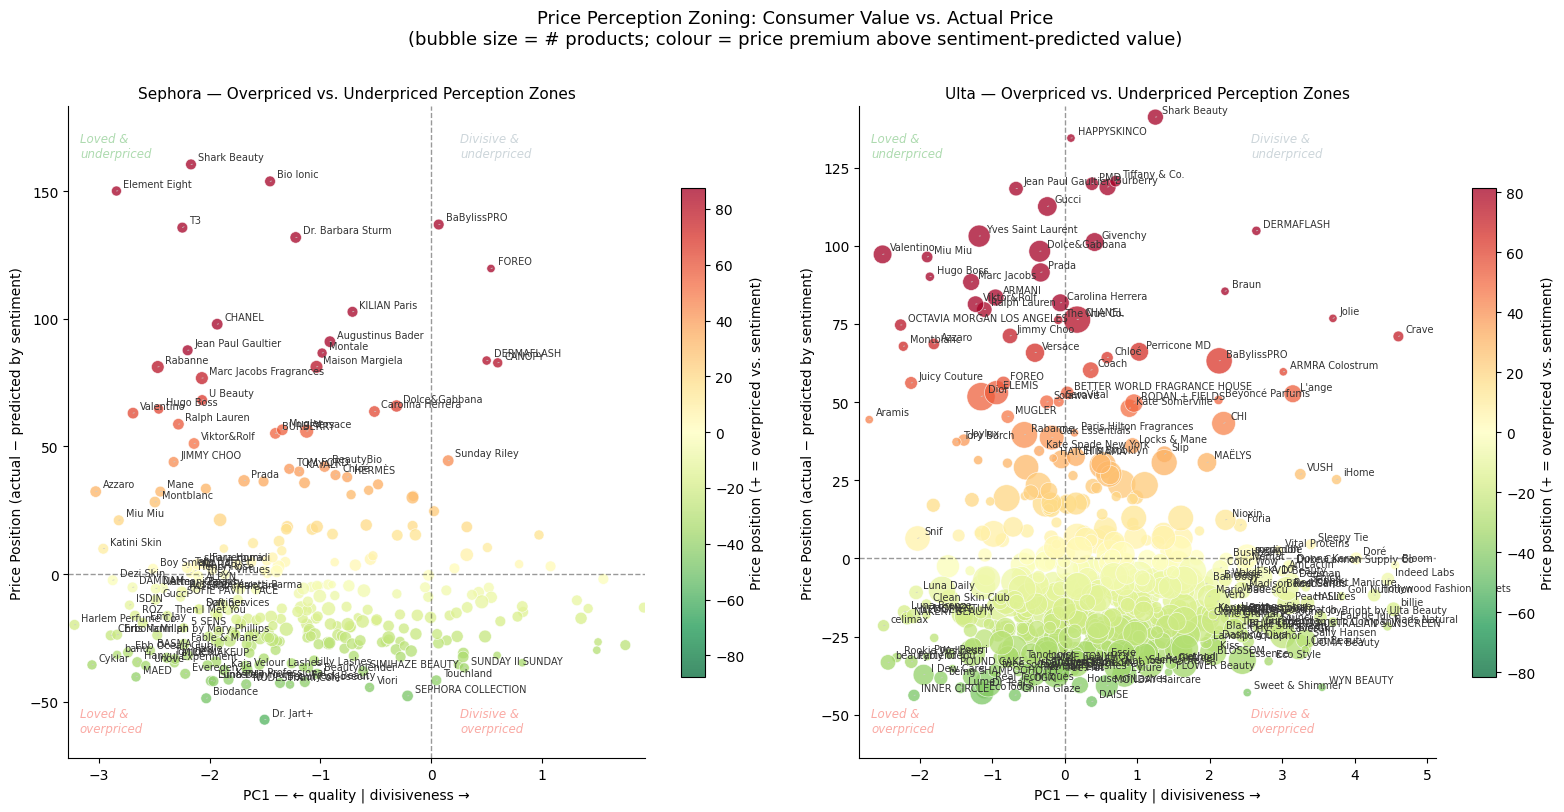

In [10]:
if "price_position" in pca_df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(16, 8))

    for ax, platform, color in [
        (axes[0], "Sephora", SEPHORA_COLOR),
        (axes[1], "Ulta",    ULTA_COLOR),
    ]:
        sub = pca_df[(pca_df["platform"] == platform) &
                     pca_df["price_position"].notna() &
                     pca_df["PC1"].notna()].copy()

        # Debug — remove after confirming both platforms populate
        print(f"{platform}: n={len(sub)}  "
              f"price_position NaN={sub['price_position'].isna().sum()}  "
              f"Inf={np.isinf(sub['price_position'].replace(np.nan, 0)).sum()}  "
              f"range=[{sub['price_position'].min():.3f}, "
              f"{sub['price_position'].max():.3f}]")

        # Safe range computation — guard against NaN/Inf
        pp_clean = sub["price_position"].replace([np.inf, -np.inf], np.nan).dropna()
        pc_clean = sub["PC1"].replace([np.inf, -np.inf], np.nan).dropna()

        if len(pp_clean) < 3 or len(pc_clean) < 3:
            ax.set_title(f"{platform} — insufficient data", fontsize=11)
            continue

        vmax    = pp_clean.abs().quantile(0.95)
        y_range = pp_clean.quantile([0.02, 0.98])
        x_range = pc_clean.quantile([0.02, 0.98])

        # Fallback if quantiles themselves are NaN
        if not np.isfinite(y_range.iloc[0]) or not np.isfinite(y_range.iloc[1]):
            y_range = pd.Series([pp_clean.min(), pp_clean.max()])
        if not np.isfinite(x_range.iloc[0]) or not np.isfinite(x_range.iloc[1]):
            x_range = pd.Series([pc_clean.min(), pc_clean.max()])

        pad_y = max((y_range.iloc[1] - y_range.iloc[0]) * 0.15, 0.01)
        pad_x = max((x_range.iloc[1] - x_range.iloc[0]) * 0.10, 0.01)

        # Use cleaned sub for plotting
        plot_sub = sub[
            sub["price_position"].between(
                float(y_range.iloc[0] - pad_y),
                float(y_range.iloc[1] + pad_y)
            ) &
            sub["PC1"].between(
                float(x_range.iloc[0] - pad_x),
                float(x_range.iloc[1] + pad_x)
            )
        ].copy()

        sc = ax.scatter(
            plot_sub["PC1"], plot_sub["price_position"],
            s=plot_sub["n_products"] * 8 + 20,
            c=plot_sub["price_position"],
            cmap="RdYlGn_r", vmin=-float(vmax), vmax=float(vmax),
            alpha=0.75, edgecolors="white", linewidths=0.5,
        )
        plt.colorbar(sc, ax=ax, shrink=0.75,
                     label="Price position (+ = overpriced vs. sentiment)")

        ax.axvline(0, color="black", lw=1, ls="--", alpha=0.4)
        ax.axhline(0, color="black", lw=1, ls="--", alpha=0.4)

        ax.set_xlim(float(x_range.iloc[0] - pad_x), float(x_range.iloc[1] + pad_x))
        ax.set_ylim(float(y_range.iloc[0] - pad_y), float(y_range.iloc[1] + pad_y))

        # Quadrant labels anchored to actual axis limits
        xl, xr = ax.get_xlim()
        yb, yt = ax.get_ylim()
        q = dict(fontsize=8.5, alpha=0.45, style="italic")
        ax.text(xl + (xr - xl) * 0.02, yt - (yt - yb) * 0.04,
                "Loved &\nunderpriced",   color=UNDER_COLOR, va="top", **q)
        ax.text(xr - (xr - xl) * 0.32,  yt - (yt - yb) * 0.04,
                "Divisive &\nunderpriced", color=NEUTRAL,    va="top", **q)
        ax.text(xl + (xr - xl) * 0.02,  yb + (yt - yb) * 0.04,
                "Loved &\noverpriced",    color=OVER_COLOR,  **q)
        ax.text(xr - (xr - xl) * 0.32,  yb + (yt - yb) * 0.04,
                "Divisive &\noverpriced", color=OVER_COLOR,  **q)

        # Label outliers within the visible range
        thr_pp = pp_clean.abs().quantile(0.80)
        thr_pc = pc_clean.abs().quantile(0.80)
        outliers = plot_sub[
            (plot_sub["price_position"].abs() > thr_pp) |
            (plot_sub["PC1"].abs() > thr_pc)
        ]
        for _, row in outliers.iterrows():
            ax.annotate(row["brand"],
                        xy=(row["PC1"], row["price_position"]),
                        xytext=(5, 3), textcoords="offset points",
                        fontsize=7, color="#333",
                        arrowprops=dict(arrowstyle="-", color="#ccc", lw=0.5))

        ax.set_xlabel("PC1 — ← quality | divisiveness →", fontsize=10)
        ax.set_ylabel("Price Position (actual − predicted by sentiment)", fontsize=10)
        ax.set_title(f"{platform} — Overpriced vs. Underpriced Perception Zones",
                     fontsize=11)
        ax.spines[["top", "right"]].set_visible(False)

    fig.suptitle("Price Perception Zoning: Consumer Value vs. Actual Price\n"
                 "(bubble size = # products; colour = price premium above "
                 "sentiment-predicted value)",
                 fontsize=13, y=1.01)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "3.2_price_perception_zones.png",
                dpi=150, bbox_inches="tight")
    plt.show()

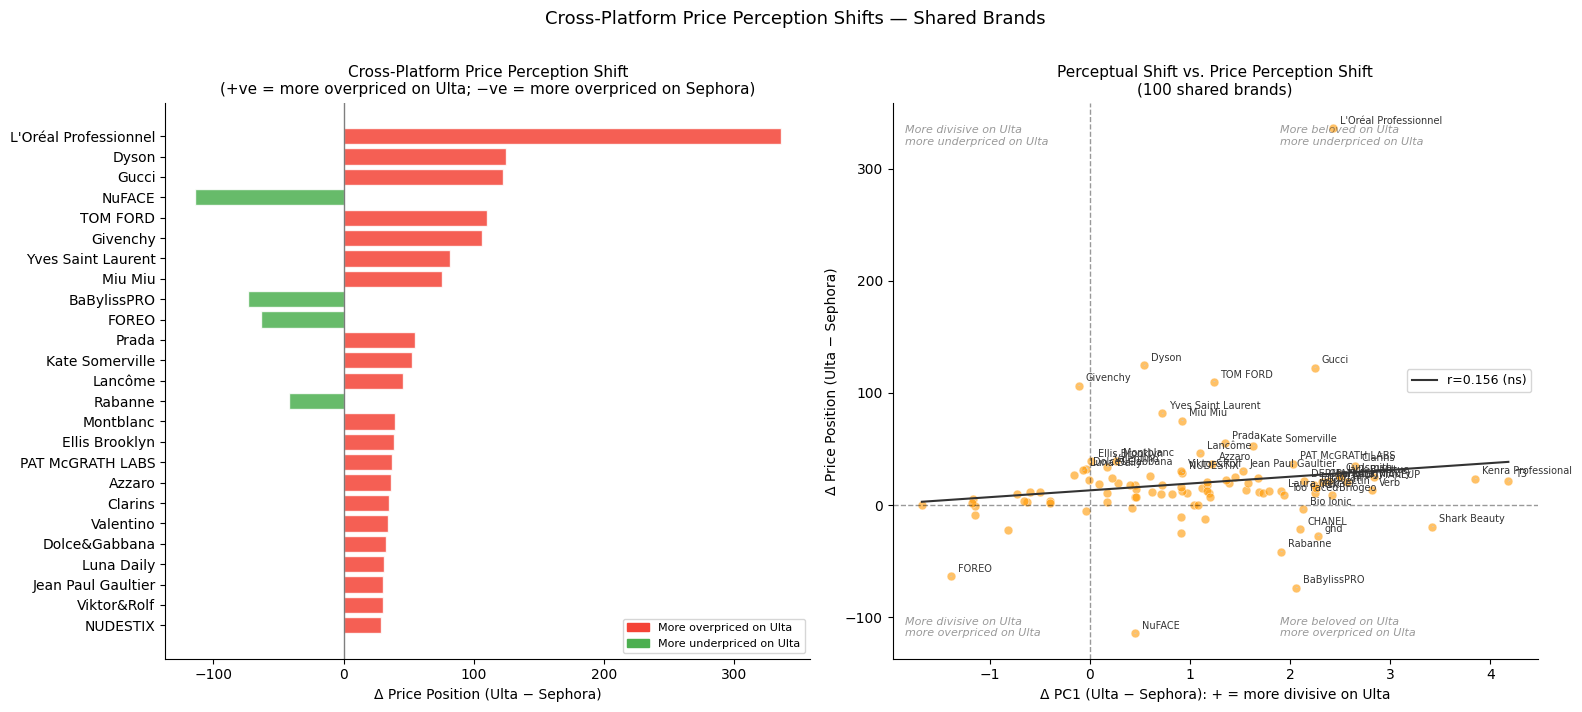

In [11]:
# For shared brands: does price perception change across platforms?
# brand is "overpriced" on Sephora but "fair" on Ulta → repositioning signal

if "price_position" in pca_df.columns:
    s_pp = (pca_df[pca_df["platform"] == "Sephora"]
            [["brand", "PC1", "PC2", "price_position", "n_products"]]
            .set_index("brand"))
    u_pp = (pca_df[pca_df["platform"] == "Ulta"]
            [["brand", "PC1", "PC2", "price_position", "n_products"]]
            .set_index("brand"))
    common = s_pp.index.intersection(u_pp.index).intersection(
        pd.Index(list(both_brands))
    )

    if len(common) > 0:
        shift_df = pd.DataFrame({
            "brand":         common,
            "pp_sephora":    s_pp.loc[common, "price_position"].values,
            "pp_ulta":       u_pp.loc[common, "price_position"].values,
            "pc1_sephora":   s_pp.loc[common, "PC1"].values,
            "pc1_ulta":      u_pp.loc[common, "PC1"].values,
        })
        shift_df["pp_shift"]  = shift_df["pp_ulta"] - shift_df["pp_sephora"]
        shift_df["pc1_shift"] = shift_df["pc1_ulta"] - shift_df["pc1_sephora"]
        shift_df = shift_df.dropna()

        fig, axes = plt.subplots(1, 2, figsize=(16, 7))

        # Panel 1: price perception shift ranked
        plot_df = shift_df.reindex(
            shift_df["pp_shift"].abs().sort_values(ascending=True).index
        ).tail(25)
        bar_colors = [OVER_COLOR if v > 0 else UNDER_COLOR
                      for v in plot_df["pp_shift"]]
        axes[0].barh(plot_df["brand"], plot_df["pp_shift"],
                     color=bar_colors, alpha=0.85, edgecolor="white")
        axes[0].axvline(0, color="black", lw=1, alpha=0.5)
        axes[0].set_xlabel("Δ Price Position (Ulta − Sephora)", fontsize=10)
        axes[0].set_title("Cross-Platform Price Perception Shift\n"
                          "(+ve = more overpriced on Ulta; −ve = more overpriced on Sephora)",
                          fontsize=11)
        axes[0].legend(handles=[
            mpatches.Patch(color=OVER_COLOR,  label="More overpriced on Ulta"),
            mpatches.Patch(color=UNDER_COLOR, label="More underpriced on Ulta"),
        ], fontsize=8)
        axes[0].spines[["top", "right"]].set_visible(False)

        # Panel 2: scatter — PC1 shift × price perception shift
        axes[1].scatter(shift_df["pc1_shift"], shift_df["pp_shift"],
                        s=40, color=SHARED_COLOR, alpha=0.6,
                        edgecolors="white", linewidths=0.5)
        axes[1].axvline(0, color="black", lw=1, ls="--", alpha=0.4)
        axes[1].axhline(0, color="black", lw=1, ls="--", alpha=0.4)

        if len(shift_df) > 5:
            m, b, r, pv, _ = stats.linregress(shift_df["pc1_shift"],
                                               shift_df["pp_shift"])
            xl = np.linspace(shift_df["pc1_shift"].min(),
                             shift_df["pc1_shift"].max(), 100)
            sig = "***" if pv < 0.001 else "**" if pv < 0.01 else \
                  "*" if pv < 0.05 else "ns"
            axes[1].plot(xl, m * xl + b, color="#333", lw=1.5,
                         label=f"r={r:.3f} ({sig})")

        # Label brands in extreme quadrants
        thr_x = shift_df["pc1_shift"].abs().quantile(0.75)
        thr_y = shift_df["pp_shift"].abs().quantile(0.75)
        for _, row in shift_df[(shift_df["pc1_shift"].abs() > thr_x) |
                                (shift_df["pp_shift"].abs() > thr_y)].iterrows():
            axes[1].annotate(row["brand"],
                             xy=(row["pc1_shift"], row["pp_shift"]),
                             xytext=(5, 3), textcoords="offset points",
                             fontsize=7, color="#333",
                             arrowprops=dict(arrowstyle="-", color="#ccc", lw=0.5))

        q = dict(fontsize=8, alpha=0.4, style="italic")
        axes[1].text(0.02, 0.96,
                     "More divisive on Ulta\nmore underpriced on Ulta",
                     transform=axes[1].transAxes, va="top", **q)
        axes[1].text(0.60, 0.96,
                     "More beloved on Ulta\nmore underpriced on Ulta",
                     transform=axes[1].transAxes, va="top", **q)
        axes[1].text(0.02, 0.04,
                     "More divisive on Ulta\nmore overpriced on Ulta",
                     transform=axes[1].transAxes, **q)
        axes[1].text(0.60, 0.04,
                     "More beloved on Ulta\nmore overpriced on Ulta",
                     transform=axes[1].transAxes, **q)

        axes[1].set_xlabel("Δ PC1 (Ulta − Sephora): + = more divisive on Ulta",
                           fontsize=10)
        axes[1].set_ylabel("Δ Price Position (Ulta − Sephora)", fontsize=10)
        axes[1].set_title("Perceptual Shift vs. Price Perception Shift\n"
                          f"({len(shift_df)} shared brands)",
                          fontsize=11)
        axes[1].legend(fontsize=9)
        axes[1].spines[["top", "right"]].set_visible(False)

        fig.suptitle("Cross-Platform Price Perception Shifts — Shared Brands",
                     fontsize=13, y=1.01)
        plt.tight_layout()
        plt.savefig(OUTPUT_DIR / "3.1_price_perception_shift.png",
                    dpi=150, bbox_inches="tight")
        plt.show()

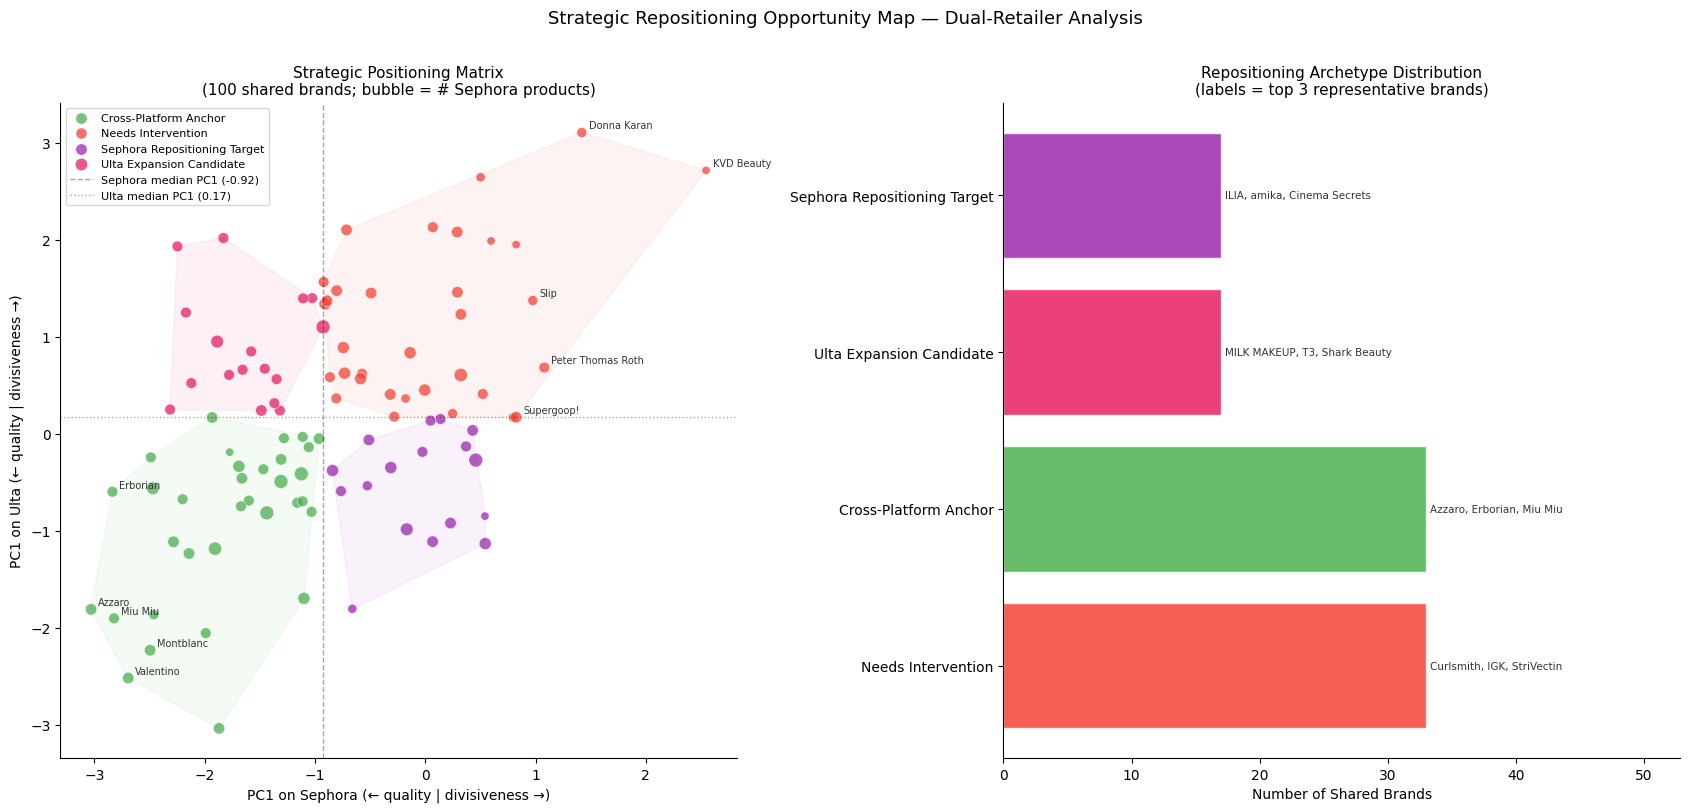

In [12]:
# Classify each shared brand into one of four repositioning archetypes:
#   Expand:   strong on Sephora (neg PC1), weak on Ulta (pos PC1) → push to Ulta
#   Protect:  strong on Ulta, weak on Sephora → Ulta native, Sephora risk
#   Leverage: strong on both → cross-platform anchor
#   Reposition: weak on both → intervention needed

if len(common) > 0:
    med_s = s_pp.loc[common, "PC1"].median()
    med_u = u_pp.loc[common, "PC1"].median()

    # Lower PC1 = higher quality/less divisive = "strong"
    is_strong_s = s_pp.loc[common, "PC1"] < med_s
    is_strong_u = u_pp.loc[common, "PC1"] < med_u

    archetype_df = pd.DataFrame({
        "brand":       common,
        "pc1_sephora": s_pp.loc[common, "PC1"].values,
        "pc1_ulta":    u_pp.loc[common, "PC1"].values,
        "strong_s":    is_strong_s.values,
        "strong_u":    is_strong_u.values,
        "n_s":         s_pp.loc[common, "n_products"].values,
        "n_u":         u_pp.loc[common, "n_products"].values,
    })

    def archetype(row):
        if row["strong_s"] and row["strong_u"]:    return "Cross-Platform Anchor"
        if row["strong_s"] and not row["strong_u"]:return "Ulta Expansion Candidate"
        if not row["strong_s"] and row["strong_u"]:return "Sephora Repositioning Target"
        return "Needs Intervention"

    archetype_df["archetype"] = archetype_df.apply(archetype, axis=1)

    ARCH_COLORS = {
        "Cross-Platform Anchor":        "#4CAF50",
        "Ulta Expansion Candidate":     SEPHORA_COLOR,
        "Sephora Repositioning Target": ULTA_COLOR,
        "Needs Intervention":           "#F44336",
    }

    fig, axes = plt.subplots(1, 2, figsize=(17, 8))

    # Panel 1: scatter — PC1 on Sephora vs PC1 on Ulta
    ax = axes[0]
    for arch, grp in archetype_df.groupby("archetype"):
        ax.scatter(grp["pc1_sephora"], grp["pc1_ulta"],
                   s=grp["n_s"] * 8 + 20,
                   color=ARCH_COLORS[arch], alpha=0.75,
                   edgecolors="white", linewidths=0.5,
                   label=arch)

    ax.axvline(med_s, color="black", lw=1, ls="--", alpha=0.35,
               label=f"Sephora median PC1 ({med_s:.2f})")
    ax.axhline(med_u, color="black", lw=1, ls=":",  alpha=0.35,
               label=f"Ulta median PC1 ({med_u:.2f})")

    # Convex hulls per archetype
    for arch, grp in archetype_df.groupby("archetype"):
        pts = grp[["pc1_sephora", "pc1_ulta"]].dropna().values
        if len(pts) >= 4:
            try:
                hull = ConvexHull(pts)
                hull_pts = np.append(hull.vertices, hull.vertices[0])
                ax.fill(pts[hull_pts, 0], pts[hull_pts, 1],
                        color=ARCH_COLORS[arch], alpha=0.06)
            except Exception:
                pass

    # Label brands at extreme positions
    for _, row in archetype_df.nlargest(5, "pc1_sephora").iterrows():
        ax.annotate(row["brand"],
                    xy=(row["pc1_sephora"], row["pc1_ulta"]),
                    xytext=(5, 3), textcoords="offset points",
                    fontsize=7, color="#333")
    for _, row in archetype_df.nsmallest(5, "pc1_sephora").iterrows():
        ax.annotate(row["brand"],
                    xy=(row["pc1_sephora"], row["pc1_ulta"]),
                    xytext=(5, 3), textcoords="offset points",
                    fontsize=7, color="#333")

    ax.set_xlabel("PC1 on Sephora (← quality | divisiveness →)", fontsize=10)
    ax.set_ylabel("PC1 on Ulta (← quality | divisiveness →)",    fontsize=10)
    ax.set_title("Strategic Positioning Matrix\n"
                 f"({len(archetype_df)} shared brands; bubble = # Sephora products)",
                 fontsize=11)
    ax.legend(fontsize=8, loc="upper left")
    ax.spines[["top", "right"]].set_visible(False)

    # Panel 2: archetype breakdown bar + brand lists
    ax2 = axes[1]
    arch_counts = archetype_df["archetype"].value_counts()
    bars = ax2.barh(arch_counts.index,
                    arch_counts.values,
                    color=[ARCH_COLORS[a] for a in arch_counts.index],
                    alpha=0.85, edgecolor="white")
    for bar, (arch, cnt) in zip(bars, arch_counts.items()):
        # Print top 3 brands for each archetype on the bar
        top_brands = (archetype_df[archetype_df["archetype"] == arch]
                      .sort_values("pc1_sephora")
                      .head(3)["brand"]
                      .tolist())
        ax2.text(bar.get_width() + 0.3,
                 bar.get_y() + bar.get_height() / 2,
                 ", ".join(top_brands),
                 va="center", fontsize=7.5, color="#333")
    ax2.set_xlabel("Number of Shared Brands", fontsize=10)
    ax2.set_title("Repositioning Archetype Distribution\n"
                  "(labels = top 3 representative brands)",
                  fontsize=11)
    ax2.set_xlim(0, arch_counts.max() * 1.6)
    ax2.spines[["top", "right"]].set_visible(False)

    fig.suptitle("Strategic Repositioning Opportunity Map — Dual-Retailer Analysis",
                 fontsize=13, y=1.01)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "3.1_repositioning_matrix.png",
                dpi=150, bbox_inches="tight")
    plt.show()

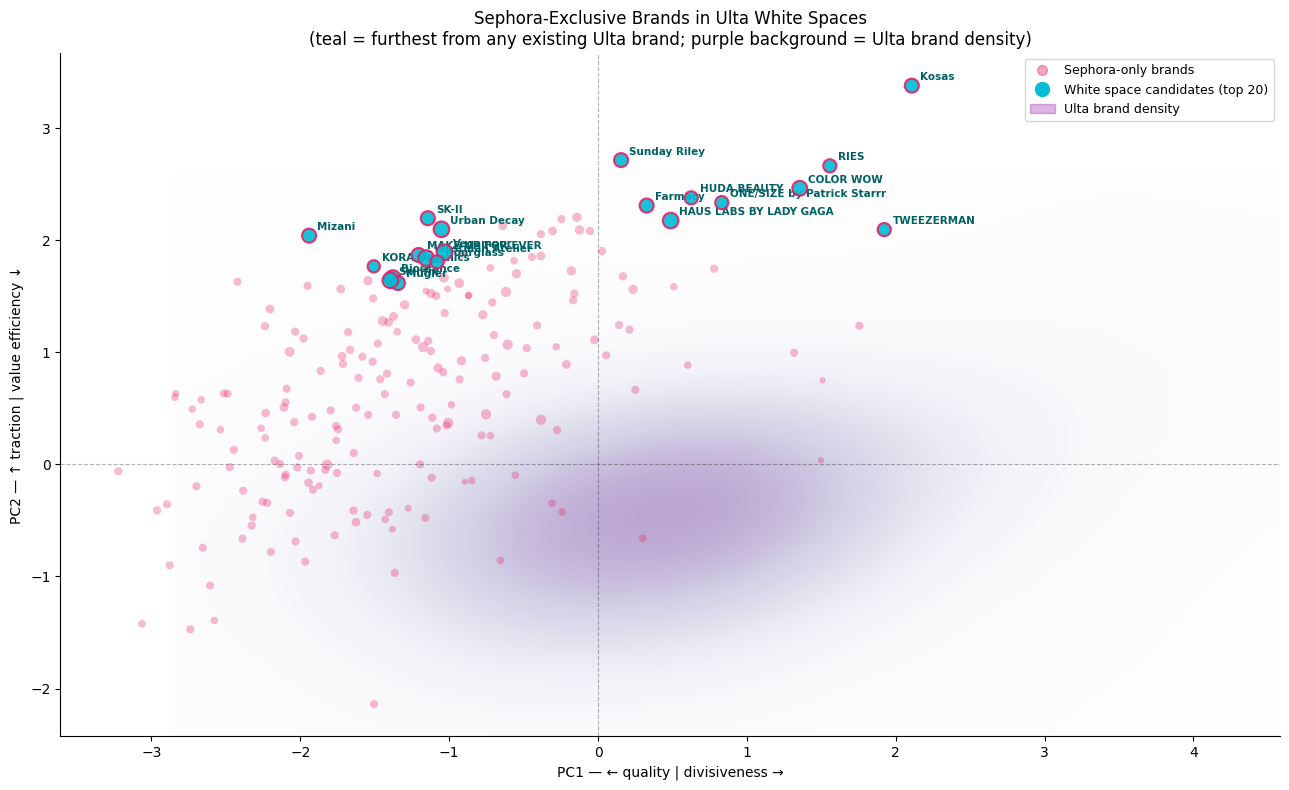


Top 20 Sephora-exclusive white space candidates for Ulta:
(ranked by distance from nearest Ulta brand in perceptual space)

                     brand    PC1   PC2  efficacy  market_traction  ulta_sparsity  n_products
                     Kosas  2.108 3.378     1.557          108.782          1.977           6
                      RIES  1.557 2.663     1.649           86.792          1.815           5
                 COLOR WOW  1.355 2.463     1.665           90.017          1.617           7
              Sunday Riley  0.155 2.714     1.851          113.632          1.603           6
ONE/SIZE by Patrick Starrr  0.832 2.335     1.750           98.632          1.552           5
               HUDA BEAUTY  0.626 2.377     1.784          107.361          1.464           5
                     SK-II -1.143 2.196     1.884          105.020          1.439           6
               Urban Decay -1.052 2.097     1.908          121.910          1.304           8
                    Mizani -1

In [13]:
# Sephora brands in regions of the map where Ulta has low density
# = brands Ulta could plausibly recruit / that represent gaps in Ulta's catalog

s_only = pca_df[pca_df["platform"] == "Sephora"].copy()
s_only = s_only[~s_only["brand"].isin(both_brands)]   # not yet on Ulta

# Score each brand by how sparse Ulta is around it
u_pts    = pca_df[pca_df["platform"] == "Ulta"][["PC1", "PC2"]].dropna().values
s_pts    = s_only[["PC1", "PC2"]].dropna()

if len(u_pts) > 0 and len(s_pts) > 0:
    from scipy.spatial.distance import cdist
    dists     = cdist(s_pts.values, u_pts, metric="euclidean")
    s_only.loc[s_pts.index, "ulta_sparsity"] = dists.min(axis=1)

    # High sparsity = far from any Ulta brand = genuine white space opportunity
    ws_candidates = (s_only.dropna(subset=["ulta_sparsity", "efficacy"])
                     .sort_values("ulta_sparsity", ascending=False)
                     .head(20))

    fig, ax = plt.subplots(figsize=(13, 8))

    # Background: Ulta density (how crowded is each zone on Ulta)
    kde_u = KernelDensity(bandwidth=0.6, kernel="gaussian")
    kde_u.fit(u_pts)
    z_u   = np.exp(kde_u.score_samples(grid)).reshape(xx.shape)
    z_u   = gaussian_filter(z_u, sigma=1.5)
    ax.imshow(z_u, extent=[x_min, x_max, y_min, y_max],
              origin="lower", cmap="Purples", aspect="auto", alpha=0.35,
              vmin=0, vmax=z_u.max())

    # All Sephora-only brands
    non_ws = s_only[~s_only["brand"].isin(ws_candidates["brand"])]
    ax.scatter(non_ws["PC1"], non_ws["PC2"],
               s=non_ws["n_products"] * 5 + 10,
               color=SEPHORA_COLOR, alpha=0.3, edgecolors="none")

    # White space candidates highlighted
    ax.scatter(ws_candidates["PC1"], ws_candidates["PC2"],
               s=ws_candidates["n_products"] * 12 + 30,
               color=WHITE_COLOR, alpha=0.9,
               edgecolors=SEPHORA_COLOR, linewidths=1.5, zorder=5)

    for _, row in ws_candidates.iterrows():
        ax.annotate(row["brand"],
                    xy=(row["PC1"], row["PC2"]),
                    xytext=(6, 4), textcoords="offset points",
                    fontsize=7.5, color="#006064", fontweight="bold",
                    arrowprops=dict(arrowstyle="-", color="#aaa", lw=0.5))

    ax.axvline(0, color="black", lw=0.8, ls="--", alpha=0.3)
    ax.axhline(0, color="black", lw=0.8, ls="--", alpha=0.3)
    ax.set_xlabel(f"PC1 — ← quality | divisiveness →", fontsize=10)
    ax.set_ylabel(f"PC2 — ↑ traction | value efficiency ↓", fontsize=10)
    ax.set_title(
        "Sephora-Exclusive Brands in Ulta White Spaces\n"
        "(teal = furthest from any existing Ulta brand; "
        "purple background = Ulta brand density)",
        fontsize=12
    )
    legend_items = [
        mlines.Line2D([], [], marker="o", color=SEPHORA_COLOR, ls="",
                      markersize=7, alpha=0.4, label="Sephora-only brands"),
        mlines.Line2D([], [], marker="o", color=WHITE_COLOR, ls="",
                      markersize=10, label="White space candidates (top 20)"),
        mpatches.Patch(color=ULTA_COLOR, alpha=0.35, label="Ulta brand density"),
    ]
    ax.legend(handles=legend_items, fontsize=9)
    ax.spines[["top", "right"]].set_visible(False)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "3.1_whitespace_candidates.png",
                dpi=150, bbox_inches="tight")
    plt.show()

    print("\nTop 20 Sephora-exclusive white space candidates for Ulta:")
    print("(ranked by distance from nearest Ulta brand in perceptual space)\n")
    print(ws_candidates[["brand", "PC1", "PC2", "efficacy",
                          "market_traction", "ulta_sparsity", "n_products"]]
          .round(3).to_string(index=False))

In [14]:
print("  3.1  DUAL-RETAILER PERCEPTUAL MAPS — SUMMARY")
print(f"\nShared brands analysed  : {len(both_brands):,}")
print(f"Sephora-exclusive brands: "
      f"{(pca_df['platform']=='Sephora').sum() - len(both_brands):,}")
print(f"Ulta-exclusive brands   : "
      f"{(pca_df['platform']=='Ulta').sum() - len(both_brands):,}")

if "archetype_df" in dir():
    print("\nRepositioning archetype breakdown:")
    for arch, cnt in archetype_df["archetype"].value_counts().items():
        brands = (archetype_df[archetype_df["archetype"] == arch]
                  .sort_values("pc1_sephora").head(5)["brand"].tolist())
        print(f"  {arch:<40} n={cnt:>3}  e.g. {', '.join(brands)}")

if "shift_df" in dir() and len(shift_df) > 0:
    print("\nLargest cross-platform price perception shifts:")
    for _, row in shift_df.reindex(
        shift_df["pp_shift"].abs().sort_values(ascending=False).index
    ).head(8).iterrows():
        direction = "more overpriced on Ulta" if row["pp_shift"] > 0 \
                    else "more overpriced on Sephora"
        print(f"  {row['brand']:<35} Δpp={row['pp_shift']:+.3f}  ({direction})")

  3.1  DUAL-RETAILER PERCEPTUAL MAPS — SUMMARY

Shared brands analysed  : 100
Sephora-exclusive brands: 201
Ulta-exclusive brands   : 455

Repositioning archetype breakdown:
  Needs Intervention                       n= 33  e.g. Curlsmith, IGK, StriVectin, Chloé, L'Occitane
  Cross-Platform Anchor                    n= 33  e.g. Azzaro, Erborian, Miu Miu, Valentino, Montblanc
  Ulta Expansion Candidate                 n= 17  e.g. MILK MAKEUP, T3, Shark Beauty, Clarins, Virtue
  Sephora Repositioning Target             n= 17  e.g. ILIA, amika, Cinema Secrets, Dermalogica, Carolina Herrera

Largest cross-platform price perception shifts:
  L'Oréal Professionnel               Δpp=+336.206  (more overpriced on Ulta)
  Dyson                               Δpp=+124.521  (more overpriced on Ulta)
  Gucci                               Δpp=+122.600  (more overpriced on Ulta)
  NuFACE                              Δpp=-114.546  (more overpriced on Sephora)
  TOM FORD                            Δpp=

## 3.1 Dual-Retailer Perceptual Maps

### Platform Topology in Shared Space

The shared PCA map places 856 brand-platform observations in a common coordinate system, and the KDE contours immediately reveal the fundamental structural difference between the two retailers. Sephora's brand density concentrates in a tight ellipse in the negative-PC1, positive-PC2 quadrant — high quality, high traction — with a long tail extending rightward into divisive territory. Ulta's density mass sits lower on PC2 and spans a broader PC1 range, its ellipse centered near zero on both axes and extending substantially further into positive PC1 than Sephora ever reaches. The two distributions overlap substantially in the mid-quality, moderate-traction zone, but the upper-left quadrant (beloved, high-visibility) is almost exclusively Sephora territory, while the right half of the map (PC1 > 2) is almost exclusively Ulta territory. This is not simply a catalog size effect — it reflects genuinely different competitive compositions, with Sephora's roster skewed toward high-satisfaction prestige brands and Ulta's extending into a mass-accessible polarizing segment that Sephora does not meaningfully occupy.

### White Space Structure

The white space maps make the directional asymmetry explicit. Sephora holds a near-total density advantage in the upper-left quadrant — the beloved, high-traction space — with virtually no Ulta presence. This region contains the concentrated KDE peak of Sephora's brand cluster and represents the most strategically differentiated zone in the entire map: brands that are simultaneously well-rated, well-reviewed, and not particularly divisive. Ulta, conversely, holds exclusive density in the mid-to-right PC1 band at neutral PC2, a zone populated by its large roster of mass and drug-store brands that generate moderate review volumes without achieving the quality consistency of Sephora's prestige core.

The practical implication is directional: Ulta's white space opportunity is upward and leftward — the beloved, high-traction quadrant — while Sephora has no structural white space problem on the quality axis but entirely lacks presence in the high-volume, accessible-price zone that Ulta dominates. These are not symmetrical gaps. Sephora's absent zone is one it may not want to enter given brand positioning; Ulta's absent zone is one it is actively trying to close through prestige shelf expansion.

### Price Perception Zones

The price perception maps reveal structurally different value contracts on each platform. On Sephora, the overpriced zone (positive price position) is populated almost exclusively by brands in the negative-PC1 range — loved brands that are nonetheless charging above what their sentiment scores would predict. The most extreme cases are hair tool and device brands: Shark Beauty, Element Eight, T3, Bio Ionic, and ghd all sit at price positions of $130–$160 above sentiment-predicted value, while scoring well on the quality axis. This is a consistent pattern: Sephora's prestige hardware brands command significant price premiums relative to the consumer experience they deliver in reviews, suggesting either that consumers tolerate the gap due to performance benefits not captured in sentiment, or that these brands benefit from a halo effect from their Sephora placement.

On Ulta, the overpriced zone has a markedly different character. The highest price positions are dominated by luxury fashion houses — Shark Beauty, HAPPYSKINCO, Jean Paul Gaultier, Burberry, Givenchy, Gucci, and YSL all sitting above $100 price position — brands whose price points are calibrated to a luxury retail context but whose Ulta reviewer base applies mass-market expectations. The overpriced zone on Ulta extends further across both PC1 quadrants than on Sephora, meaning Ulta has overpriced brands across the quality spectrum, not just in the beloved segment. The underpriced zone on Ulta (negative price position, bottom of map) is large and populated by a distinct set of brands: mass-accessible skincare, haircare, and drugstore-adjacent lines whose review scores meaningfully exceed what their prices would predict. This is Ulta's value efficiency advantage made visible — a substantial cohort of brands delivering consumer experience well above their price tier.

### Cross-Platform Price Perception Shifts

Among the 100 shared brands, the dominant direction of price perception shift is clear: 18 of the top 25 shifted brands are more overpriced on Ulta than on Sephora, with only NuFACE, BaBylissPRO, FOREO, and Rabanne moving in the opposite direction. L'Oréal Professionnel shows the largest shift at Δpp = +336, an extreme outlier driven by its professional haircare pricing being severely misaligned with Ulta's general consumer reviewer base. Dyson (+124), Gucci (+123), TOM FORD (+110), and Givenchy (+106) follow, all luxury or premium-hardware brands whose price positioning is contextually appropriate at Sephora but generates a perceived value deficit at Ulta.

The scatter plot of perceptual shift versus price perception shift (r = 0.156, ns) reveals that the two types of cross-platform change are essentially uncorrelated. A brand becoming more divisive on Ulta does not predict whether it will also become more overpriced — these are independent channel effects operating through different mechanisms. The practical interpretation is that perceptual repositioning (moving on the quality-divisiveness axis) and price perception repositioning (moving in the over/underpriced dimension) require separate strategic interventions and cannot be addressed by a single lever.

### Strategic Repositioning Archetypes

The repositioning matrix classifies the 100 shared brands into four archetypes of roughly equal size across the two performance quadrants. Cross-Platform Anchors (n=33) are the most strategically stable group, scoring well on quality on both platforms — Azzaro, Erborian, and Miu Miu are representative, all sitting in the negative-PC1 zone on both axes, suggesting consistent perception of quality and low divisiveness regardless of channel. These brands have achieved something rare: their positioning is genuinely portable across retail contexts with different consumer demographics. Needs Intervention (n=33) is the mirror image — brands underperforming on quality on both platforms, represented by Curlsmith, IGK, and StriVectin. The fact that this group is as large as the Anchor group indicates that cross-platform perception problems are not rare exceptions but a structural feature of the shared brand landscape.

Ulta Expansion Candidates (n=17) are brands performing well on Sephora but not on Ulta — MILK MAKEUP, T3, and Shark Beauty are the lead examples. These are brands where Sephora's curation and customer base generate strong quality signals that Ulta's broader, more heterogeneous reviewer pool does not replicate. The strategic question for these brands is whether the Ulta performance gap reflects a product-market fit problem with Ulta's customer base or a presentation and discovery problem solvable through merchandising. Sephora Repositioning Targets (n=17) run in the opposite direction: ILIA, amika, and Cinema Secrets perform better on Ulta's quality axis than on Sephora's. For brands in this group, Ulta may be the more natural long-term home, or Sephora placement may be generating misaligned consumer expectations that suppress quality perception.

### Sephora-Exclusive White Space Candidates

The 20 Sephora-exclusive brands furthest from any existing Ulta brand in perceptual space represent the most analytically grounded answer to the question of what Ulta is missing. All 20 sit in the upper portion of the map (positive PC2, meaning high traction) and span both sides of the quality axis. The top candidates by perceptual distance — Kosas (sparsity 1.977), RIES (1.815), COLOR WOW (1.617), Sunday Riley (1.603) — are all high-efficacy, high-traction brands with review velocities above 85 reviews per month, meaning they are not quiet niche performers but active community brands with demonstrated consumer engagement. Their absence from Ulta is a genuine catalog gap, not a deliberate positioning choice on Ulta's part given that several comparable brands already populate Ulta's prestige shelf. Notably, Mizani (traction 136, sparsity 1.271) and Urban Decay (traction 121, sparsity 1.304) appear in the list as Sephora exclusives despite being well-known brands — confirming that the white space is not a function of brand obscurity but of channel exclusivity decisions that may be renegotiable.